# 10 – Interaktív Pipeline Orchestrátor

Egyetlen felületen látható, hogyan hat a Nut-detekció pontosságára:
- **Preprocessing** (CLAHE, Blur, Normalizálás)
- **Profiling mód** (Linear / Power / Max-pooling / Sobel-X / Auto)
- **ROI stratégia** (MediaPipe / Legacy Geo / Extended Nut Margin)
- **Detection paraméterek** (Nut szélességhatárok, Peak threshold)

Minden logika `src/` modulokból importálódik. A notebook csak GUI + vizualizáció.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import contextlib
%matplotlib inline

In [2]:
import pandas as pd
from pathlib import Path

import src.config as _src_config
from src.config import CFG, PREPROCESSING_CONFIG, PATHS
from src.fretboard import run_v14_pipeline, IntensityFretDetector, GeometricFretDetector
from src.preprocess import ImagePreprocessor
from src.viz import draw_master_dashboard, debug_nut_detection, PipelineVisualizer

# ── Manifest betöltése + képlista összeállítása ───────────────────────────────
manifest = pd.read_csv(PATHS["manifest"])

# Validációs képek osztályonként 3-3 db (gyors iterációhoz)
sample_rows = (
    manifest[manifest["split"] == "val"]
    .groupby("class")
    .head(3)
    .reset_index(drop=True)
)
# Training képekből is vegyünk, ha kevés a val
train_sample = (
    manifest[manifest["split"] == "train"]
    .groupby("class")
    .head(2)
    .reset_index(drop=True)
)
all_samples = pd.concat([sample_rows, train_sample], ignore_index=True)

image_options = {
    f"[{r['class']}] {r['filename']}  ({r['split']})": r.to_dict()
    for _, r in all_samples.iterrows()
}
print(f"Betöltött képek száma: {len(image_options)}")

Betöltött képek száma: 40


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIG UTILITIES
#
#  config_patch() – kontextuskezelő (pipeline futása alatt ideiglenes override)
#  update_config() – Architecture Switcher (globálisan patcheli a CFG-t + widgetek)
# ═══════════════════════════════════════════════════════════════════════════════

@contextlib.contextmanager
def config_patch(**overrides):
    """Ideiglenesen felülírja a CFG / PREPROCESSING_CONFIG értékeit.

    A context manager kilépésekor visszaállítja az eredeti értékeket.
    Thread-safe Jupyter futtatás esetén (egy cella fut egyszerre).
    """
    cfg_backup  = {}
    prep_backup = {}
    for k, v in overrides.items():
        if k in _src_config.CFG:
            cfg_backup[k]  = _src_config.CFG[k]
            _src_config.CFG[k] = v
        elif k in _src_config.PREPROCESSING_CONFIG:
            prep_backup[k] = _src_config.PREPROCESSING_CONFIG[k]
            _src_config.PREPROCESSING_CONFIG[k] = v
    try:
        yield
    finally:
        _src_config.CFG.update(cfg_backup)
        _src_config.PREPROCESSING_CONFIG.update(prep_backup)


def update_config(overrides: dict):
    """Architecture Switcher – globálisan felülírja a CFG / widget értékeket.

    Speciális kulcs: ``'PROFILING_MODE'`` → a widget értékét is frissíti.

    Példa::

        update_config({'PROFILING_MODE': 'sobel'})
        update_config({'PROFILING_MODE': 'max', 'clahe_enabled': False})
        update_config({'nut_min_width_px': 4.0, 'nut_max_width_px': 25.0})
    """
    profiling_mode = overrides.pop('PROFILING_MODE', None)
    if profiling_mode is not None:
        profiling_mode = str(profiling_mode).lower()
        valid = ['linear', 'power', 'max', 'sobel', 'auto']
        if profiling_mode not in valid:
            print(f"[update_config] WARN: ismeretlen mód {profiling_mode!r}, valid: {valid}")
        else:
            if 'w_profile_mode' in globals():
                w_profile_mode.value = profiling_mode
            print(f"[update_config] PROFILING_MODE → {profiling_mode}")

    for k, v in overrides.items():
        if k in _src_config.CFG:
            _src_config.CFG[k] = v
            print(f"[update_config] CFG[{k!r}] = {v!r}")
        elif k in _src_config.PREPROCESSING_CONFIG:
            _src_config.PREPROCESSING_CONFIG[k] = v
            print(f"[update_config] PREPROCESSING_CONFIG[{k!r}] = {v!r}")
            if k == 'clahe_enabled' and 'w_clahe' in globals():
                w_clahe.value = bool(v)
            elif k == 'blur_enabled' and 'w_blur' in globals():
                w_blur.value = bool(v)
        else:
            print(f"[update_config] WARN: {k!r} nem ismert CFG kulcs")

In [ ]:
import ipywidgets as widgets
from IPython.display import display

_LBL_STYLE = {"font_weight": "bold"}
_SLIDER_LAYOUT = widgets.Layout(width="320px")

# ── Preprocessing ─────────────────────────────────────────────────────────────
w_clahe      = widgets.Checkbox(value=True,  description="CLAHE",
                                layout=widgets.Layout(width="160px"))
w_blur       = widgets.Checkbox(value=False, description="Gaussian Blur",
                                layout=widgets.Layout(width="160px"))
w_blur_ksize = widgets.IntSlider(
    value=3, min=1, max=15, step=2,
    description="Blur ksize",
    style={"description_width": "80px"},
    layout=_SLIDER_LAYOUT,
)
w_normalize  = widgets.Checkbox(value=False, description="Normalizálás",
                                layout=widgets.Layout(width="160px"))

def _on_blur_toggle(change):
    w_blur_ksize.disabled = not change["new"]
w_blur.observe(_on_blur_toggle, names="value")
_on_blur_toggle({"new": False})

preproc_box = widgets.VBox([
    widgets.HTML("<b>Preprocessing</b>"),
    widgets.HBox([w_clahe, w_normalize]),
    widgets.HBox([w_blur,  w_blur_ksize]),
], layout=widgets.Layout(border="1px solid #ccc", padding="8px", margin="4px",
                          min_width="340px"))

# ── ROI Strategy ──────────────────────────────────────────────────────────────
w_roi_strategy = widgets.ToggleButtons(
    options=["MediaPipe", "Legacy (Geo)", "Extended Nut Margin"],
    value="MediaPipe",
    description="ROI:",
    style={"description_width": "40px", "button_width": "155px"},
)

# ── Profiling Mode ────────────────────────────────────────────────────────────
w_profile_mode = widgets.ToggleButtons(
    options=[
        ("LINEAR", "linear"),
        ("POWER", "power"),
        ("MAX", "max"),
        ("SOBEL-X", "sobel"),
        ("AUTO", "auto"),
    ],
    value="auto",
    description="Profil:",
    button_style="info",
    style={"description_width": "50px", "button_width": "90px"},
    tooltips=[
        "Lineáris: mean(gray) – baseline",
        "Power (x²): mean((gray/255)^2) – csúcserősítés",
        "Max-pooling: max(gray) – shear-robusztus",
        "Sobel-X: |∂I/∂x|.sum – élesítő, egyenes bundoknál legjobb",
        "Auto: shear-eredmény + SNR alapján Sobel-X / Max-pooling közül választ",
    ],
)

w_profile_active = widgets.HTML(
    "<b>Aktív stratégia:</b> <span style='color:#7f8c8d'>run után jelenik meg</span>"
 )

strategy_box = widgets.VBox([
    widgets.HTML("<b>ROI Stratégia</b>"),
    w_roi_strategy,
    widgets.HTML("<b>Profiling Mód</b>"),
    w_profile_mode,
    w_profile_active,
], layout=widgets.Layout(border="1px solid #ccc", padding="8px", margin="4px"))

# ── Detection Params ──────────────────────────────────────────────────────────
w_nut_min_w   = widgets.FloatSlider(
    value=float(CFG.get("nut_min_width_px", 6.0)), min=1.0, max=20.0, step=0.5,
    description="Nut min w (px)",
    style={"description_width": "115px"}, layout=_SLIDER_LAYOUT,
)
w_nut_max_w   = widgets.FloatSlider(
    value=float(CFG.get("nut_max_width_px", 18.0)), min=5.0, max=60.0, step=0.5,
    description="Nut max w (px)",
    style={"description_width": "115px"}, layout=_SLIDER_LAYOUT,
)
w_peak_height = widgets.FloatSlider(
    value=0.12, min=0.01, max=0.50, step=0.01,
    readout_format=".2f",
    description="Peak height",
    style={"description_width": "115px"}, layout=_SLIDER_LAYOUT,
)
w_shear_thr   = widgets.FloatSlider(
    value=0.20, min=0.05, max=2.0, step=0.05,
    readout_format=".2f",
    description="Shear corr. thr (°)",
    style={"description_width": "115px"}, layout=_SLIDER_LAYOUT,
)

detection_box = widgets.VBox([
    widgets.HTML("<b>Detection Params</b>"),
    w_nut_min_w, w_nut_max_w, w_peak_height, w_shear_thr,
], layout=widgets.Layout(border="1px solid #ccc", padding="8px", margin="4px",
                          min_width="360px"))

# ── Image selector + Run ──────────────────────────────────────────────────────
w_image_select = widgets.Dropdown(
    options=list(image_options.keys()),
    description="Kép:",
    style={"description_width": "40px"},
    layout=widgets.Layout(width="520px"),
)
w_run_btn    = widgets.Button(
    description="▶  Run Pipeline",
    button_style="success",
    layout=widgets.Layout(width="170px", height="36px"),
)
w_status     = widgets.Label("Kész. Válassz képet és kattints Run-ra.")
w_debug_chk  = widgets.Checkbox(value=False, description="Debug View (profil-összehasonlítás + Nut-diagnosztika)")
w_output     = widgets.Output()
w_debug_out  = widgets.Output()

print("Widgetek definiálva. ✓")

Widgetek definiálva. ✓


In [ ]:
from scipy.ndimage import gaussian_filter1d


# ─────────────────────────────────────────────────────────────────────────────
#  High-res figure rendering for inline notebook output
# ─────────────────────────────────────────────────────────────────────────────

_HIGH_RES_FIGURE_RC = {
    "figure.dpi": 180,
    "savefig.dpi": 220,
}


@contextlib.contextmanager
def high_res_figure_context():
    """Temporarily render notebook figures at a higher pixel density."""
    with plt.rc_context(_HIGH_RES_FIGURE_RC):
        yield


# ─────────────────────────────────────────────────────────────────────────────
#  Debug: 4-profil összehasonlítás (09-es notebook stílusában)
# ─────────────────────────────────────────────────────────────────────────────

def _draw_profile_comparison(canon_bgr: np.ndarray, result: dict = None):
    """4-profil összehasonlítás: Linear / Power / Max-pooling / Sobel-X."""
    gray  = cv2.cvtColor(canon_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    sigma = 1.5

    def _ns(p):
        p = gaussian_filter1d(p, sigma)
        mx = float(p.max())
        return p / mx if mx > 1e-6 else p

    profiles = {
        "Lineáris":    _ns(gray.mean(axis=0)),
        "Power (x²)": _ns(((gray / 255.0) ** 2).mean(axis=0)),
        "Max-pooling": _ns(gray.max(axis=0)),
        "Sobel-X":     _ns(np.abs(cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)).sum(axis=0)),
    }
    colors  = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
    nut_x   = ((result or {}).get("nut") or {}).get("nut_x")
    frets   = (result or {}).get("fret_xs_filt", [])

    with high_res_figure_context():
        fig, axes = plt.subplots(2, 2, figsize=(14, 5.5), sharex=True, sharey=True)
        fig.suptitle("Debug: Profil-stratégia összehasonlítás (azonos kép, 4 mód)",
                     fontsize=11, fontweight="bold")

        for ax, (name, prof), color in zip(axes.flat, profiles.items(), colors):
            xs = np.arange(len(prof))
            ax.fill_between(xs, prof, alpha=0.22, color=color)
            ax.plot(xs, prof, color=color, lw=1.5)
            ax.axhline(0.30, color="#888", ls=":", lw=0.9, label="thr=0.30")
            if nut_x is not None:
                ax.axvline(nut_x, color="#2ecc71", lw=2.0, label=f"Nut @{int(nut_x)}px")
            for i, fx in enumerate(frets):
                ax.axvline(fx, color="#e74c3c", lw=0.8, alpha=0.7,
                           label="Frets" if i == 0 else "")
            ax.set_xlim(0, len(prof))
            ax.set_ylim(0, 1.05)
            ax.set_title(name, fontsize=10, color=color, fontweight="bold")
            ax.legend(fontsize=7, loc="upper right", framealpha=0.7)
            ax.grid(alpha=0.2)
            ax.tick_params(labelsize=7)

        plt.tight_layout()
        plt.show()


# ─────────────────────────────────────────────────────────────────────────────
#  Pipeline callback
# ─────────────────────────────────────────────────────────────────────────────

def run_pipeline_from_widgets(_btn=None):
    """Widget értékek alapján futtatja a pipeline-t, majd a Master Dashboardot jeleníti meg."""
    w_status.value  = "⏳ Futtatás..."
    w_run_btn.disabled = True

    with w_output:
        w_output.clear_output(wait=True)
        try:
            img_row = image_options[w_image_select.value]

            # ── 1. Preprocessing config ───────────────────────────────────────
            prep_cfg = {
                "clahe_enabled":        bool(w_clahe.value),
                "clahe_clip_limit":     2.0,
                "clahe_tile_grid_size": (8, 8),
                "blur_enabled":         bool(w_blur.value),
                "blur_ksize":           int(w_blur_ksize.value),
                "normalize_enabled":    bool(w_normalize.value),
                "normalize_method":     "minmax",
            }
            preprocessor = ImagePreprocessor(config=prep_cfg)

            # ── 2. Detektor + ROI stratégia ───────────────────────────────────
            roi_choice = w_roi_strategy.value
            prof_mode  = w_profile_mode.value

            if roi_choice == "Legacy (Geo)":
                fret_detector = GeometricFretDetector()
            else:
                fret_detector = IntensityFretDetector(
                    mode=prof_mode,
                    peak_height=float(w_peak_height.value),
                )

            cfg_overrides = {
                "nut_min_width_px": float(w_nut_min_w.value),
                "nut_max_width_px": float(w_nut_max_w.value),
            }
            if roi_choice == "Extended Nut Margin":
                cfg_overrides["nut_extend_amin_margin_px"] = 200
                cfg_overrides["nut_fallback_extend_px"]    = 150

            # ── 3. Pipeline futtatás (ideiglenes config patch) ────────────────
            with config_patch(**cfg_overrides):
                result = run_v14_pipeline(
                    img_row,
                    fret_detector=fret_detector,
                    preprocessor=preprocessor,
                )

            # ── 4. Master Dashboard ───────────────────────────────────────────
            with high_res_figure_context():
                fig = draw_master_dashboard(result, show=False)
                plt.show()
                plt.close(fig)

            # ── 5. Szöveges összefoglaló ──────────────────────────────────────
            ok_str = "✓ OK" if result.get("ok") else f"✗  {result.get('invalid_reason', '?')}"
            nut    = result.get("nut")
            frets  = result.get("fret_xs_filt", [])
            cov    = (result.get("fit") or {}).get("coverage_ratio", 0.0)
            shear  = result.get("shear") or {}
            active_profile = result.get("intensity_profile_mode", prof_mode)
            auto_info = result.get("intensity_auto_strategy") or {}
            auto_reason = auto_info.get("reason", "n/a")

            if prof_mode == "auto":
                reason_txt = (
                    f"{auto_reason}"
                    f" | tilt={auto_info.get('residual_tilt_deg', 'n/a')}"
                    f" | conf={auto_info.get('hough_confidence', 'n/a')}"
                )
                w_profile_active.value = (
                    f"<b>Aktív stratégia:</b> "
                    f"<span style='color:#2c3e50'>{str(active_profile).upper()}</span> "
                    f"<span style='color:#7f8c8d'>(AUTO: {reason_txt})</span>"
                )
            else:
                w_profile_active.value = (
                    f"<b>Aktív stratégia:</b> "
                    f"<span style='color:#2c3e50'>{str(active_profile).upper()}</span>"
                )

            print(f"─── Pipeline összefoglaló ───────────────────────────────")
            print(f"  Státusz   : {ok_str}")
            print(f"  ROI       : {roi_choice}")
            print(f"  Profil    : {prof_mode}  →  aktív: {result.get('intensity_profile_mode', 'n/a')}")
            if prof_mode == "auto":
                print(
                    f"  Auto-döntés: {auto_reason} "
                    f"(tilt={auto_info.get('residual_tilt_deg', 'n/a')}, "
                    f"conf={auto_info.get('hough_confidence', 'n/a')}, "
                    f"n_lines={auto_info.get('n_lines', 'n/a')})"
                )
            print(f"  Nut       : {'@'+str(int(nut['nut_x']))+'px  FWHM='+str(round(nut.get('width_px',0),1))+'px  side='+str(nut.get('side','?')) if nut else 'nem detektált'}")
            print(f"  Frets     : {len(frets)}  |  Coverage: {cov:.3f}")
            print(f"  Shear     : {'korrigált @ '+str(round(shear.get('shear_angle_deg',0),2))+'°' if shear.get('corrected') else str(round(shear.get('shear_angle_deg',0),2))+'° (nem korrigált)'}")
            print(f"  CLAHE={w_clahe.value}  Blur={w_blur.value}(k={w_blur_ksize.value})  Normalize={w_normalize.value}")

        except Exception as exc:
            import traceback
            print(f"HIBA a pipeline futtatása közben:\n{traceback.format_exc()}")
            result = None

    # ── 6. Opcionális Debug View ──────────────────────────────────────────────
    with w_debug_out:
        w_debug_out.clear_output(wait=True)
        if w_debug_chk.value and result is not None:
            print("─── Debug View ──────────────────────────────────────────")

            # Nut-diagnosztika (debug_nut_detection a viz.py-ből)
            with high_res_figure_context():
                dbg_fig = debug_nut_detection(result, show=False)
                if dbg_fig is not None:
                    plt.show()
                    plt.close(dbg_fig)

            # 4-profil összehasonlítás (09-es stílusban)
            canon = result.get("canon")
            if canon is not None:
                _draw_profile_comparison(canon, result)

    w_status.value    = "✓ Kész."
    w_run_btn.disabled = False


# Regisztrálás
w_run_btn.on_click(run_pipeline_from_widgets)
print("Callback regisztrálva. ✓")

Callback regisztrálva. ✓


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  GUI MEGJELENÍTÉSE
#  Futtasd ezt a cellát: megjelenik az interaktív vezérlőpult.
# ═══════════════════════════════════════════════════════════════════════════════

header = widgets.HTML(
    "<h2 style='margin:4px 0; color:#2c3e50'>Gitárnyak-felismerő – Interaktív Pipeline Orchestrátor</h2>"
    "<p style='margin:2px 0; color:#7f8c8d; font-size:0.9em'>"
    "Válassz képet, állítsd be a paramétereket, majd kattints <b>Run Pipeline</b>-ra.</p>"
)

controls_row = widgets.HBox(
    [preproc_box, strategy_box, detection_box],
    layout=widgets.Layout(flex_flow="row wrap", gap="4px"),
)

run_row = widgets.HBox(
    [w_image_select, w_run_btn, w_status],
    layout=widgets.Layout(align_items="center", gap="8px", margin="6px 0"),
)

panel = widgets.VBox([
    header,
    widgets.HTML("<hr style='border:1px solid #bdc3c7; margin:6px 0'/>"),
    controls_row,
    widgets.HTML("<hr style='border:1px solid #bdc3c7; margin:6px 0'/>"),
    run_row,
    w_debug_chk,
    w_output,
    w_debug_out,
])

display(panel)

---

## Architecture Switcher – Programmatikus API

A GUI-n kívül az `update_config()` függvénnyel programmatikusan is változtatható
a pipeline globális konfigurációja a notebook futása alatt:

```python
# Profilmód Sobel-X-re állítása (widget is frissül)
update_config({'PROFILING_MODE': 'sobel'})

# Átkapcsolás Max-pooling-ra, CLAHE kikapcsolásával
update_config({'PROFILING_MODE': 'max', 'clahe_enabled': False})

# Nut szélességhatárok módosítása
update_config({'nut_min_width_px': 4.0, 'nut_max_width_px': 30.0})

# Trapézoid clamp bekapcsolása
update_config({'trapezoid_clamp_enabled': True, 'trapezoid_clamp_margin_px': 80})
```

A `config_patch(**overrides)` kontextuskezelő csak a `with` blokkon belül hat
(visszaállítja az értékeket kilépéskor) – ez biztonságos egyedi kísérleteknél.

In [7]:
# ── Architecture Switcher példák (opcionális, manuálisan futtatandó) ──────────
# Módosítja a widgetet ÉS a globális konfigurációt, majd újrafuttathatod a GUI-t.

# update_config({'PROFILING_MODE': 'sobel'})
# update_config({'PROFILING_MODE': 'max'})
# update_config({'PROFILING_MODE': 'linear', 'clahe_enabled': False})
# update_config({'nut_min_width_px': 3.0, 'nut_max_width_px': 25.0})

print("Architecture Switcher cella betöltve. A fenti sorok kommentből kivéve futtathatók.")

Architecture Switcher cella betöltve. A fenti sorok kommentből kivéve futtathatók.


---

## Gyors Sobel-X vs Max-pooling összehasonlítás

Futtasd az alábbi cellát: **ugyanazon a képen** egymás után lefuttatja
a Sobel-X és Max-pooling módot, és egymás mellé teszi az eredményt.
Ez a legdirektebb válasz a kérdésre: *hogyan változik a detekció, ha átkapcsolok?*

I0000 00:00:1779232785.790385 1281223 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779232785.794921 1281239 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779232785.812751 1281227 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779232785.840170 1281228 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779232786.192035 1281229 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


  [outer_edges_v9] vonalak: 3 | bal outlier: nem | jobb outlier: nem
  [outer_edges_v9] Bal oldal bővítve: -54.3px
  [outer_edges_v9] Jobb oldal bővítve: +54.3px
  [outer_edges_v9] szétválasztás: 108.6px (klaszter: 181.0px | bővítés: 54.3px)
  [extend_amin] a_min 2102.3 → 1009.1 (landmark_min=1129.1, margin=120px)
  [trapezoid_v9] span=3846.4px | w_start=108.6px | w_end=108.6px | area=459591px²
  [nut_detect_v12] side_hint=left | median=2879 | peak=8903 | ratio=3.09 | fwhm=7.0px
  [nut_detect_v12] nut találat: left @ x=17px (fwhm=7.0px)
  [shear_corr] n=25 | α=-1.35° | conf=1.00 | s=-0.0236 → korrigált
  [nut_detect_v12] side_hint=left | median=2619 | peak=11968 | ratio=4.57 | fwhm=10.0px
  [nut_detect_v12] nut találat: left @ x=134px (fwhm=10.0px)
  [IntensityFretDetector] mode=sobel | shear=res=1.35° conf=1.00
  [fret_fit v11] nut-anchored | scale=1164.6px | cov=38% (5/13)
  [fret_fit v11] nut-anchored | scale=1164.6px | cov=38% (5/13)
  [sobel ]  ok=True  frets=6  cov=0.385  nut=@13

/tmp/ipykernel_1281134/1967240145.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


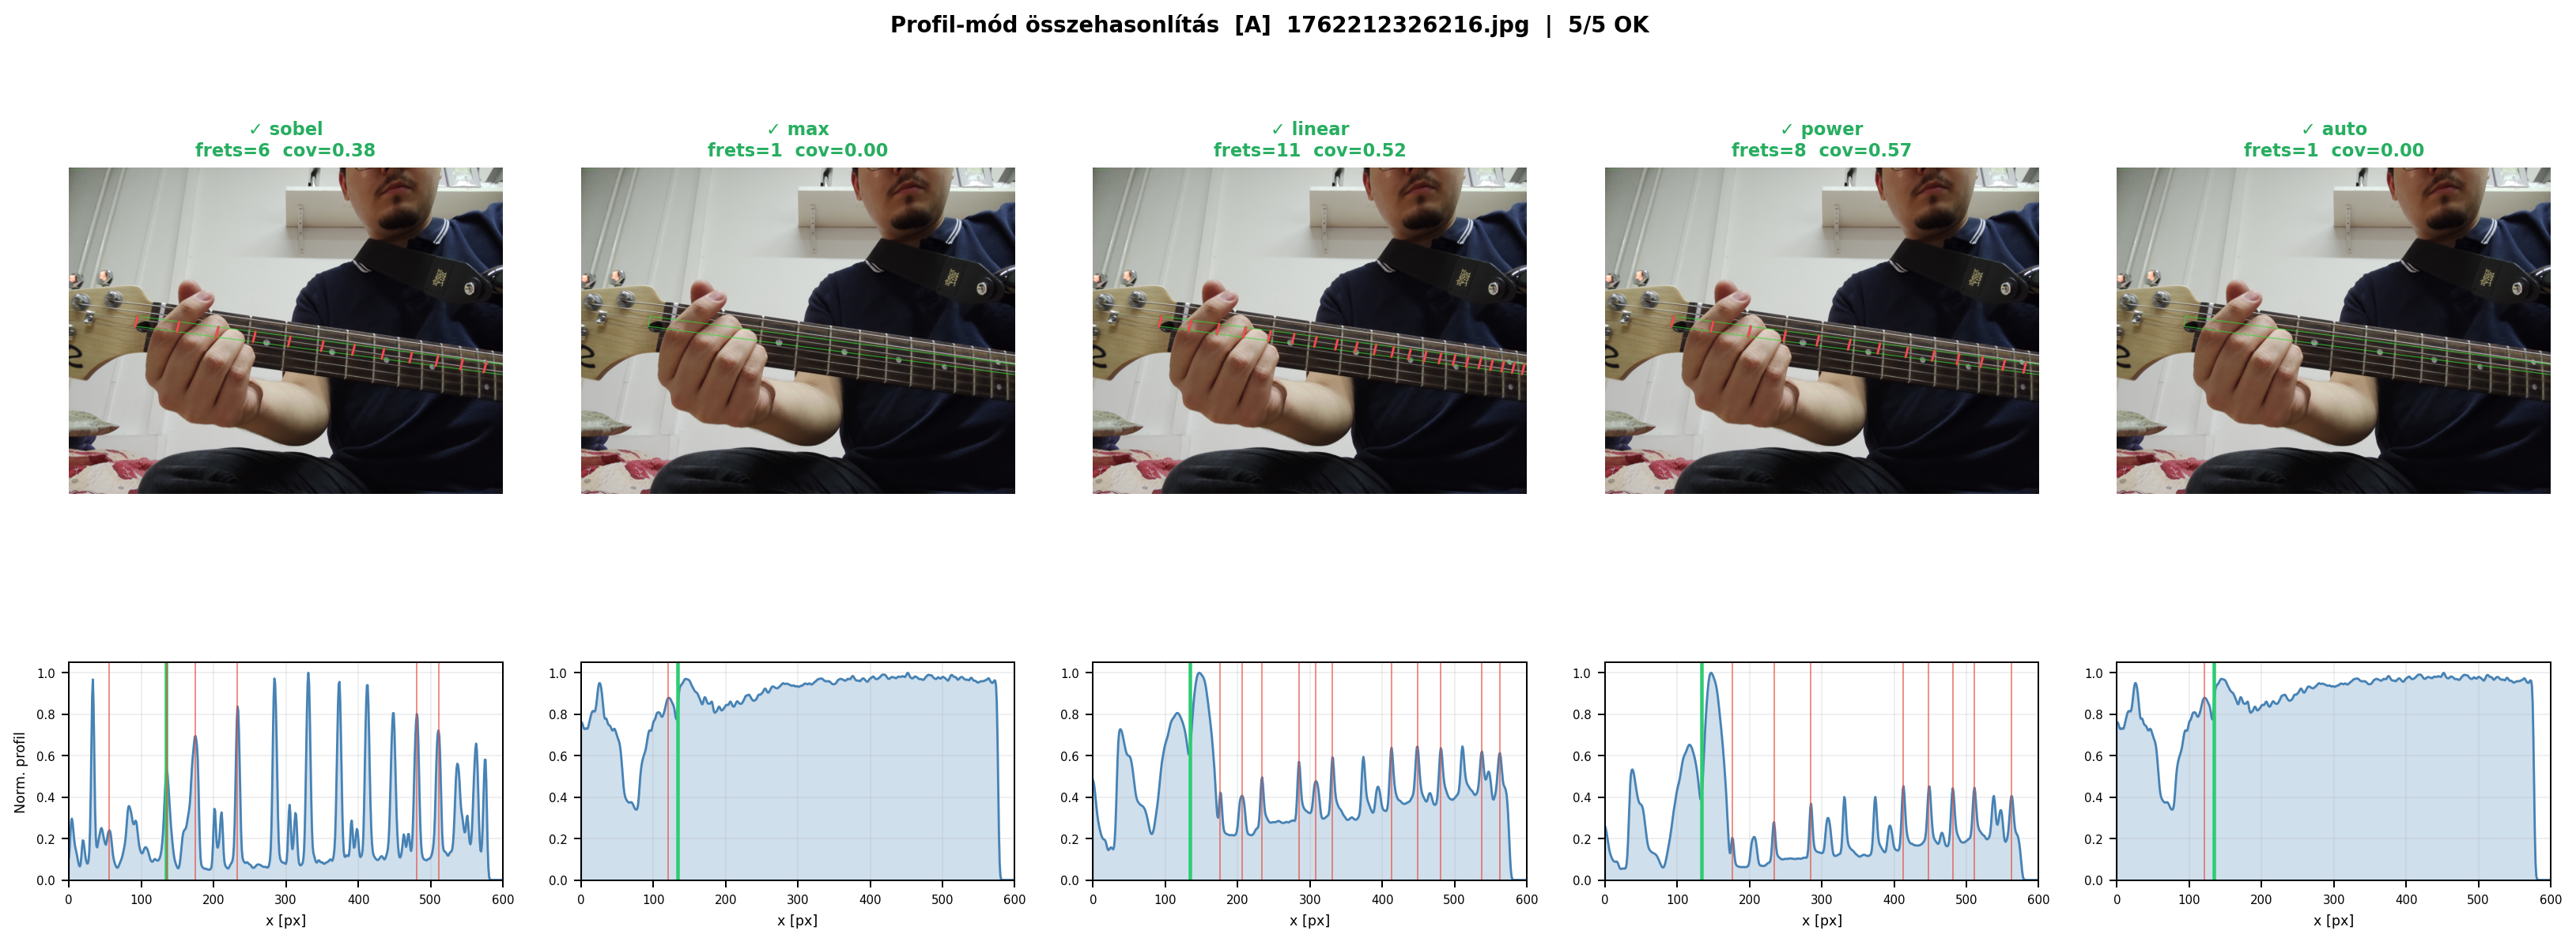

In [8]:
from src.viz import PipelineVisualizer
import matplotlib.gridspec as gridspec

def compare_profiling_modes(img_key: str = None, modes=None):
    """Futtat több profiling módot ugyanazon a képen, majd egymás mellé rajzolja.

    Ha ``img_key`` None, a jelenlegi dropdown értékét veszi.
    ``modes`` alapból: ['sobel', 'max', 'linear', 'power', 'auto'].
    """
    if modes is None:
        modes = ["sobel", "max", "linear", "power", "auto"]
    if img_key is None:
        img_key = w_image_select.value

    img_row     = image_options[img_key]
    preprocessor = ImagePreprocessor(config={
        "clahe_enabled":        bool(w_clahe.value),
        "clahe_clip_limit":     2.0,
        "clahe_tile_grid_size": (8, 8),
        "blur_enabled":         bool(w_blur.value),
        "blur_ksize":           int(w_blur_ksize.value),
        "normalize_enabled":    bool(w_normalize.value),
        "normalize_method":     "minmax",
    })

    results = {}
    for mode in modes:
        det = IntensityFretDetector(mode=mode, peak_height=float(w_peak_height.value))
        r   = run_v14_pipeline(img_row, fret_detector=det, preprocessor=preprocessor)
        results[mode] = r
        cov   = (r.get("fit") or {}).get("coverage_ratio", 0.0)
        frets = r.get("fret_xs_filt", [])
        nut   = r.get("nut")
        print(f"  [{mode:6s}]  ok={r.get('ok',False)}  frets={len(frets)}  cov={cov:.3f}  "
              f"nut={'@'+str(int(nut['nut_x']))+'px' if nut else 'n/a'}")

    # ── Összehasonlítás ábra ──────────────────────────────────────────────────
    n     = len(modes)
    n_ok  = sum(1 for r in results.values() if r.get("ok"))
    with high_res_figure_context():
        fig   = plt.figure(figsize=(4.5 * n, 7))
        gs    = gridspec.GridSpec(2, n, height_ratios=[3, 1.5], hspace=0.35, wspace=0.18)

        cls   = next(iter(results.values())).get("class", "?")
        fig.suptitle(
            f"Profil-mód összehasonlítás  [{cls}]  {img_key.split(']')[1].split('(')[0].strip()}"
            f"  |  {n_ok}/{n} OK",
            fontsize=11, fontweight="bold",
        )

        viz = PipelineVisualizer()
        for col, (mode, r) in enumerate(results.items()):
            img_bgr = r.get("img")
            nut     = r.get("nut")
            frets   = r.get("fret_xs_filt", [])
            profile = r.get("intensity_profile")
            cov     = (r.get("fit") or {}).get("coverage_ratio", 0.0)
            ok_lbl  = "✓" if r.get("ok") else "✗"

            # Overlay kép
            ax_img = fig.add_subplot(gs[0, col])
            if img_bgr is not None and r.get("ok"):
                ax_img.imshow(viz.draw_fretboard_overlay(img_bgr, r)[:, :, ::-1])
            elif img_bgr is not None:
                ax_img.imshow(img_bgr[:, :, ::-1])
            ax_img.set_title(
                f"{ok_lbl} {mode}\nfrets={len(frets)}  cov={cov:.2f}",
                fontsize=9, fontweight="bold",
                color=("#27ae60" if r.get("ok") else "#c0392b"),
            )
            ax_img.axis("off")

            # Profil
            ax_p = fig.add_subplot(gs[1, col])
            if profile is not None:
                xs = np.arange(len(profile))
                ax_p.fill_between(xs, profile, alpha=0.25, color="steelblue")
                ax_p.plot(xs, profile, color="steelblue", lw=1.1)
                if nut is not None:
                    ax_p.axvline(nut["nut_x"], color="#2ecc71", lw=1.8)
                for fx in frets:
                    ax_p.axvline(fx, color="#e74c3c", lw=0.7, alpha=0.7)
                ax_p.set_xlim(0, len(profile))
                ax_p.set_ylim(0, 1.05)
            else:
                ax_p.text(0.5, 0.5, "n/a", ha="center", va="center",
                          transform=ax_p.transAxes, color="gray")
            ax_p.grid(alpha=0.2)
            ax_p.tick_params(labelsize=6)
            ax_p.set_xlabel("x [px]", fontsize=7)
            if col == 0:
                ax_p.set_ylabel("Norm. profil", fontsize=7)

        plt.tight_layout()
        plt.show()


 # Futtatás:
compare_profiling_modes()